In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

municipality_types = pd.read_parquet(
    "../data/processed/municipality_economic_types.parquet"
)

economic_type_profiles = pd.read_csv(
    "../data/processed/economic_type_profiles.csv",
    index_col=0
)

monthly_type_shares = pd.read_csv(
    "../data/processed/monthly_economic_type_shares.csv"
)

municipality_types["date"] = pd.to_datetime(
    municipality_types["date"]
)

monthly_type_shares["date"] = pd.to_datetime(
    monthly_type_shares["date"]
)

print("municipality_types:", municipality_types.shape)
print("economic_type_profiles:", economic_type_profiles.shape)
print("monthly_type_shares:", monthly_type_shares.shape)

municipality_types: (50521, 4)
economic_type_profiles: (3, 5)
monthly_type_shares: (72, 4)


In [2]:
economic_type_profiles

,food_share,health_share,marketplaces_share,catering_share,transport_share
economic_type,,,,,
0,0.603,0.063,0.231,0.032,0.071
1,0.498,0.085,0.204,0.103,0.110
2,0.680,0.066,0.140,0.036,0.079


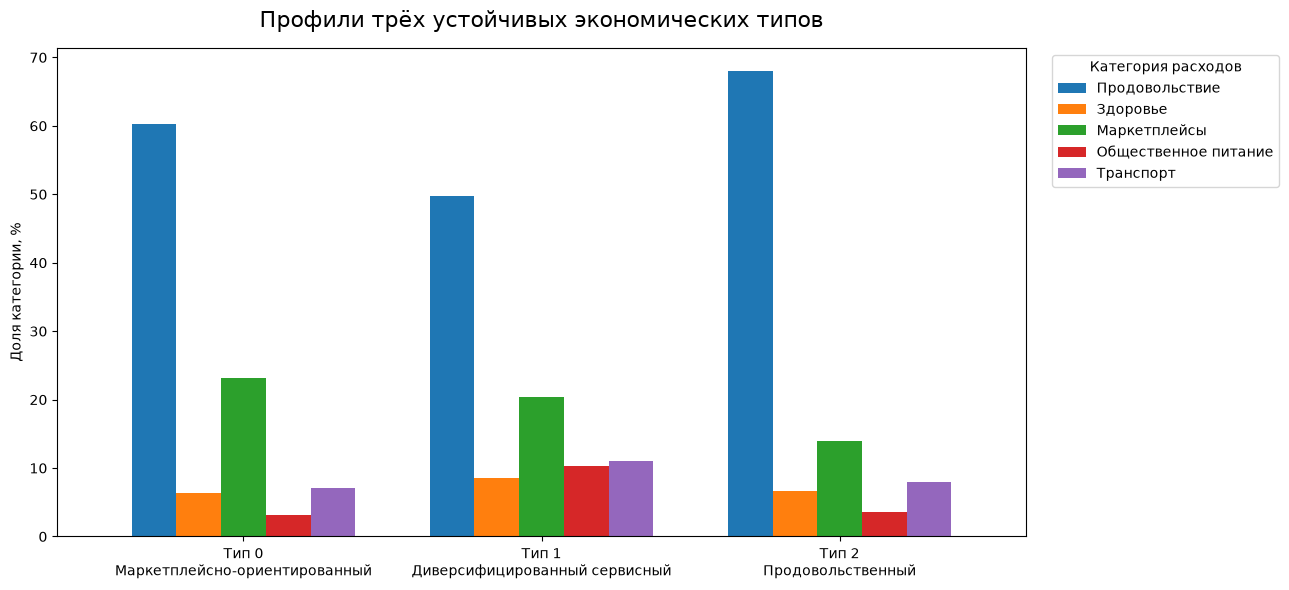

In [3]:
profile_plot = economic_type_profiles.copy()

profile_plot.index = [
    "Тип 0\nМаркетплейсно-ориентированный",
    "Тип 1\nДиверсифицированный сервисный",
    "Тип 2\nПродовольственный"
]

profile_plot.columns = [
    "Продовольствие",
    "Здоровье",
    "Маркетплейсы",
    "Общественное питание",
    "Транспорт"
]

profile_plot = profile_plot * 100

ax = profile_plot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75
)

ax.set_title(
    "Профили трёх устойчивых экономических типов",
    fontsize=16,
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Доля категории, %")

ax.legend(
    title="Категория расходов",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
monthly_plot = monthly_type_shares.copy()

monthly_plot["economic_type"] = monthly_plot["economic_type"].astype(int)

monthly_plot["type_name"] = monthly_plot["economic_type"].map({
    0: "Маркетплейсно-ориентированный",
    1: "Диверсифицированный сервисный",
    2: "Продовольственный"
})

monthly_plot.head()

,date,economic_type,n_municipalities,share,type_name
0,2023-01-01,0,191,0.089127,Маркетплейсно-ориентированный
1,2023-01-01,1,399,0.186188,Диверсифицированный сервисный
2,2023-01-01,2,1553,0.724685,Продовольственный
3,2023-02-01,0,338,0.157870,Маркетплейсно-ориентированный
4,2023-02-01,1,469,0.219057,Диверсифицированный сервисный


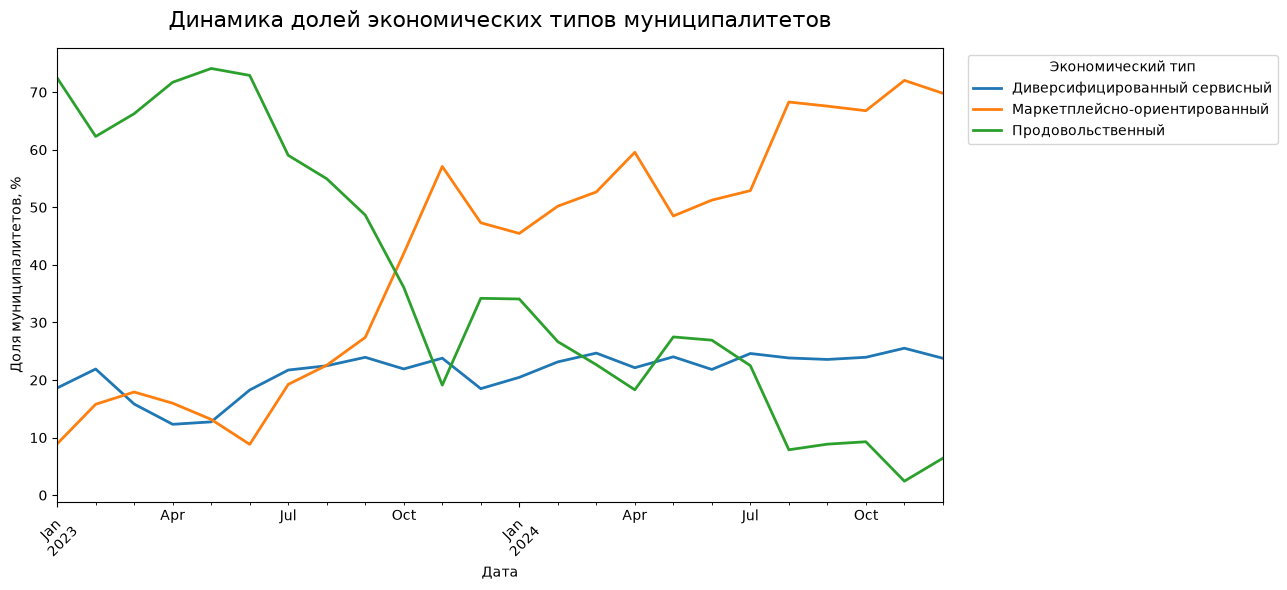

In [5]:
pivot_monthly = monthly_plot.pivot(
    index="date",
    columns="type_name",
    values="share"
)

ax = (pivot_monthly * 100).plot(
    figsize=(13, 6),
    linewidth=2
)

ax.set_title(
    "Динамика долей экономических типов муниципалитетов",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Дата")
ax.set_ylabel("Доля муниципалитетов, %")

ax.legend(
    title="Экономический тип",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
transitions = municipality_types[
    ["territory_id", "date", "economic_type"]
].copy()

transitions["next_date"] = (
    transitions.groupby("territory_id")["date"].shift(-1)
)

transitions["next_type"] = (
    transitions.groupby("territory_id")["economic_type"].shift(-1)
)

transitions = transitions[
    transitions["next_date"].notna()
    & (
        transitions["next_date"]
        == transitions["date"] + pd.DateOffset(months=1)
    )
].copy()

transitions["next_type"] = transitions["next_type"].astype(int)

print("Количество переходов:", len(transitions))
transitions.head()

Количество переходов: 48223


,territory_id,date,economic_type,next_date,next_type
0,1,2023-01-01,1,2023-02-01,1
1,2,2023-01-01,1,2023-02-01,1
2,3,2023-01-01,0,2023-02-01,0
3,4,2023-01-01,0,2023-02-01,0
4,5,2023-01-01,0,2023-02-01,0


In [7]:
transition_counts = pd.crosstab(
    transitions["economic_type"],
    transitions["next_type"]
)

transition_shares = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
) * 100

transition_counts.index = [
    "Маркетплейсно-ориентированный",
    "Диверсифицированный сервисный",
    "Продовольственный"
]

transition_counts.columns = [
    "Маркетплейсно-ориентированный",
    "Диверсифицированный сервисный",
    "Продовольственный"
]

transition_shares.index = transition_counts.index
transition_shares.columns = transition_counts.columns

transition_shares.round(1)

,Маркетплейсно-ориентированный,Диверсифицированный сервисный,Продовольственный
Маркетплейсно-ориентированный,88.1,2.9,9.0
Диверсифицированный сервисный,6.2,92.8,1.0
Продовольственный,16.0,1.4,82.7


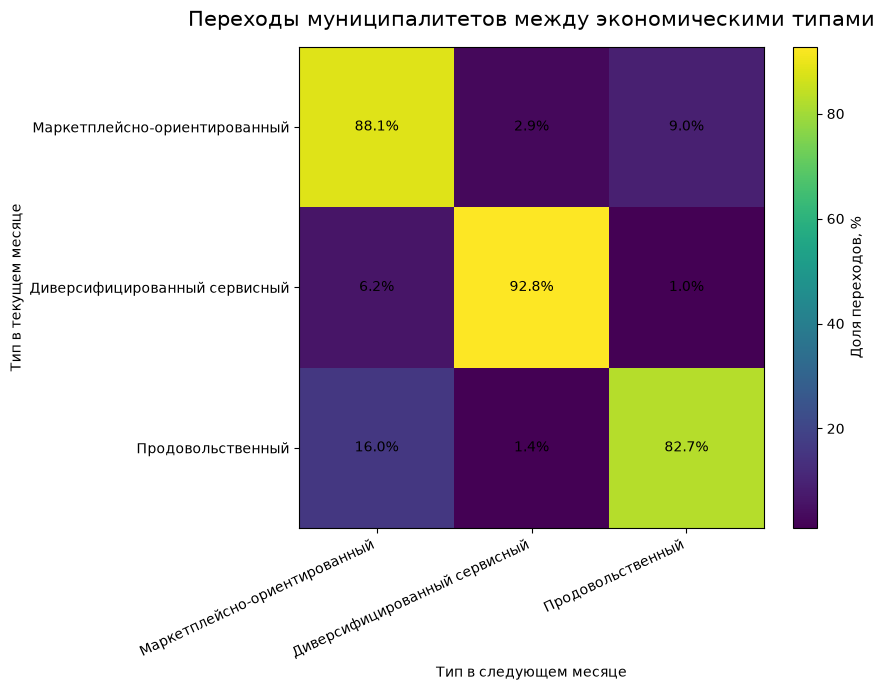

In [8]:
plt.figure(figsize=(9, 7))

plt.imshow(
    transition_shares.values,
    aspect="auto"
)

plt.colorbar(
    label="Доля переходов, %"
)

plt.xticks(
    range(3),
    transition_shares.columns,
    rotation=25,
    ha="right"
)

plt.yticks(
    range(3),
    transition_shares.index
)

plt.title(
    "Переходы муниципалитетов между экономическими типами",
    fontsize=15,
    pad=15
)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            f"{transition_shares.iloc[i, j]:.1f}%",
            ha="center",
            va="center"
        )

plt.xlabel("Тип в следующем месяце")
plt.ylabel("Тип в текущем месяце")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/transition_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
import plotly.graph_objects as go

print("Plotly работает")

Plotly работает


In [10]:
type_names = {
    0: "Маркетплейсно-ориентированный",
    1: "Диверсифицированный сервисный",
    2: "Продовольственный"
}

flow_table = (
    transitions
    .groupby(["economic_type", "next_type"])
    .size()
    .reset_index(name="value")
)

flow_table["source_name"] = flow_table["economic_type"].map(type_names)
flow_table["target_name"] = flow_table["next_type"].map(type_names)

flow_table

,economic_type,next_type,value,source_name,target_name
0,0,0,17157,Маркетплейсно-ориентированный,Маркетплейсно-ориентированный
1,0,1,568,Маркетплейсно-ориентированный,Диверсифицированный сервисный
2,0,2,1744,Маркетплейсно-ориентированный,Продовольственный
3,1,0,637,Диверсифицированный сервисный,Маркетплейсно-ориентированный
4,1,1,9532,Диверсифицированный сервисный,Диверсифицированный сервисный
5,1,2,106,Диверсифицированный сервисный,Продовольственный
6,2,0,2950,Продовольственный,Маркетплейсно-ориентированный
7,2,1,256,Продовольственный,Диверсифицированный сервисный
8,2,2,15273,Продовольственный,Продовольственный


In [11]:
node_labels = [
    "Маркетплейсно-ориентированный",
    "Диверсифицированный сервисный",
    "Продовольственный"
]

node_index = {
    name: i
    for i, name in enumerate(node_labels)
}

source = flow_table["source_name"].map(node_index)
target = flow_table["target_name"].map(node_index)
value = flow_table["value"]

fig = go.Figure(
    go.Sankey(
        arrangement="snap",
        node=dict(
            label=node_labels,
            pad=25,
            thickness=25
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title_text="Переходы муниципалитетов между экономическими типами",
    font_size=12,
    width=1000,
    height=600
)

fig.show()

In [12]:
fig.write_html(
    "../outputs/figures/economic_type_sankey.html",
    include_plotlyjs="cdn"
)

flow_table.to_csv(
    "../outputs/tables/economic_type_flows.csv",
    index=False
)

print("Sankey сохранён.")
print("Файл: outputs/figures/economic_type_sankey.html")
print("Таблица потоков: outputs/tables/economic_type_flows.csv")

Sankey сохранён.
Файл: outputs/figures/economic_type_sankey.html
Таблица потоков: outputs/tables/economic_type_flows.csv


In [13]:
similarity_comparison = pd.read_csv(
    "../data/processed/similarity_method_comparison.csv"
)

similarity_comparison

,method,n_clusters,modularity,silhouette,calinski_harabasz
0,Euclidean,19,0.813972,0.178424,914.598833
1,Cosine,33,0.808789,0.136176,684.233570


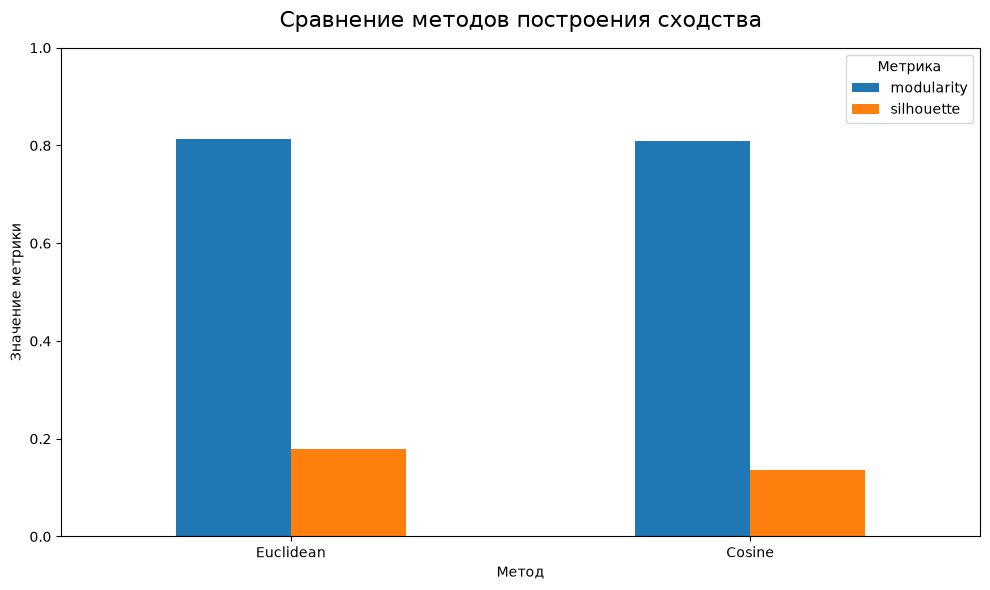

In [ ]:
metrics_to_plot = [
    "modularity",
    "silhouette"
]

comparison_plot = similarity_comparison.set_index("method")[metrics_to_plot]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Сравнение методов построения сходства",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Метод")
ax.set_ylabel("Значение метрики")

plt.xticks(rotation=0)
plt.ylim(0, 1)

ax.legend(
    title="Метрика"
)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/similarity_methods_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

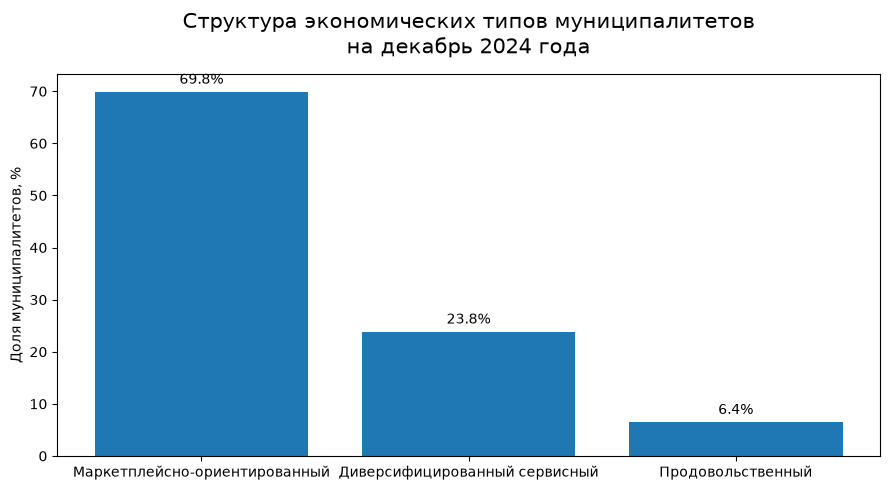

In [19]:
# Декабрь 2024
final_month = monthly_plot[
    monthly_plot["date"] == monthly_plot["date"].max()
].copy()

final_month = final_month.sort_values("economic_type")

plt.figure(figsize=(9, 5))

bars = plt.bar(
    final_month["type_name"],
    final_month["share"] * 100
)

plt.title(
    "Структура экономических типов муниципалитетов\nна декабрь 2024 года",
    fontsize=15,
    pad=15
)

plt.ylabel("Доля муниципалитетов, %")
plt.xlabel("")

plt.xticks(rotation=0)

for bar, value in zip(bars, final_month["share"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/final_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

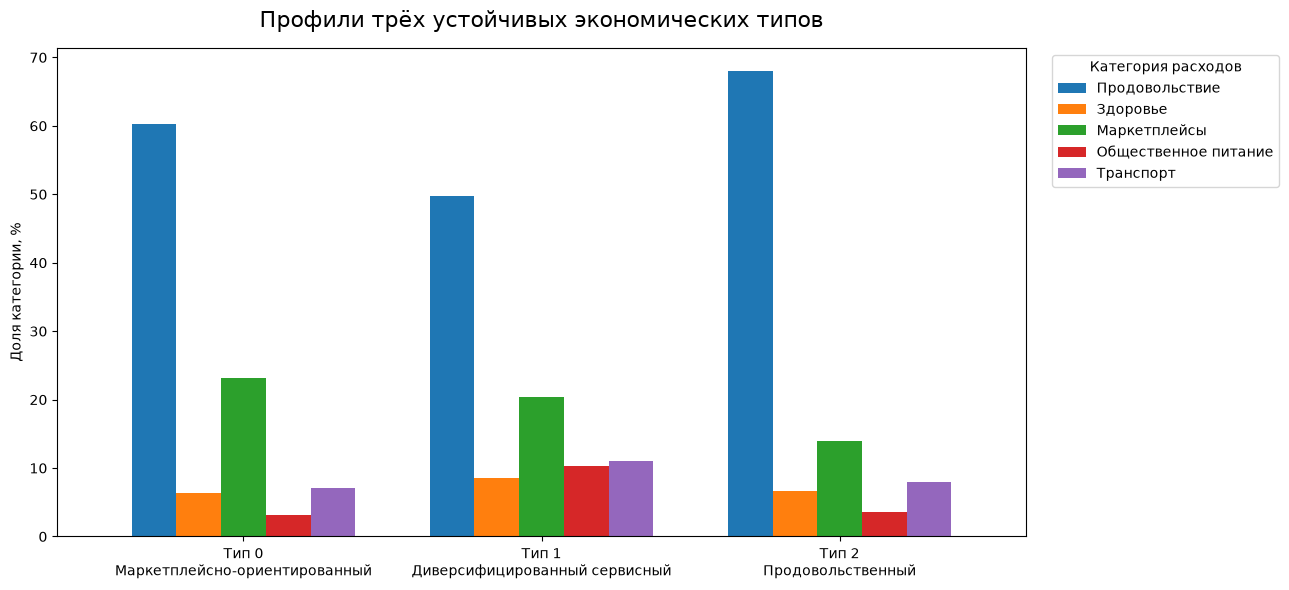

In [25]:
profile_plot = economic_type_profiles.copy()

profile_plot.index = [
    "Тип 0\nМаркетплейсно-ориентированный",
    "Тип 1\nДиверсифицированный сервисный",
    "Тип 2\nПродовольственный"
]

profile_plot.columns = [
    "Продовольствие",
    "Здоровье",
    "Маркетплейсы",
    "Общественное питание",
    "Транспорт"
]

profile_plot = profile_plot * 100

ax = profile_plot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75
)

ax.set_title(
    "Профили трёх устойчивых экономических типов",
    fontsize=16,
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Доля категории, %")

ax.legend(
    title="Категория расходов",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/economic_type_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

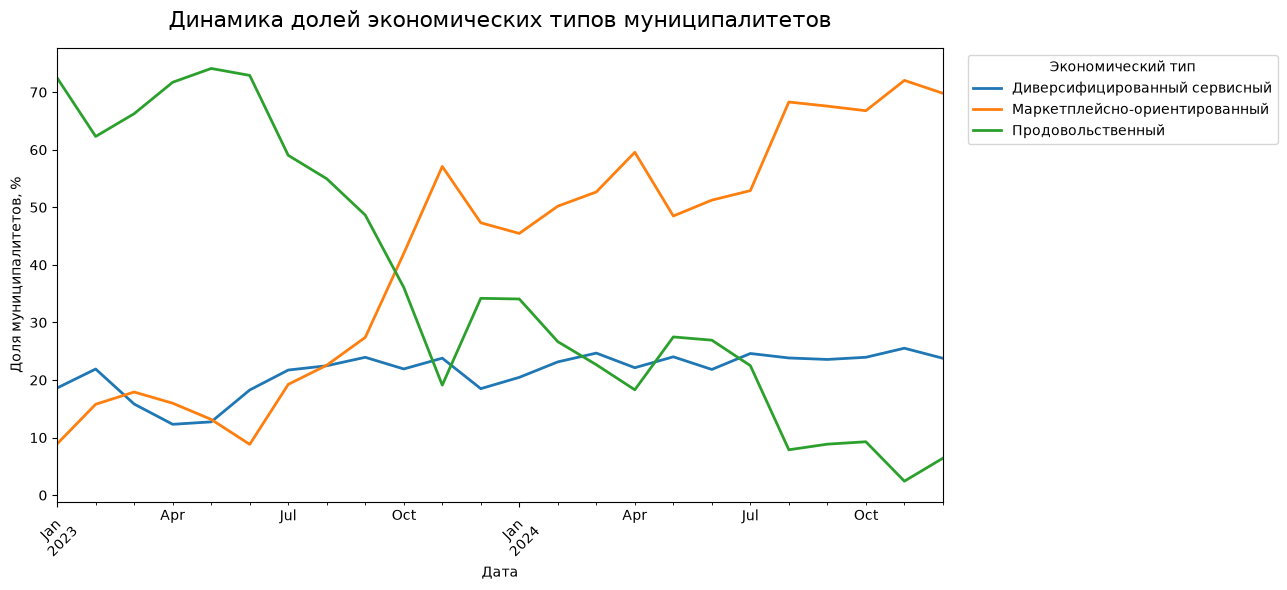

In [26]:
pivot_monthly = monthly_plot.pivot(
    index="date",
    columns="type_name",
    values="share"
)

ax = (pivot_monthly * 100).plot(
    figsize=(13, 6),
    linewidth=2
)

ax.set_title(
    "Динамика долей экономических типов муниципалитетов",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Дата")
ax.set_ylabel("Доля муниципалитетов, %")

ax.legend(
    title="Экономический тип",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/economic_type_dynamics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
final_profiles = economic_type_profiles.copy() * 100

final_profiles.index = [
    "Маркетплейсно-ориентированный",
    "Диверсифицированный сервисный",
    "Продовольственный"
]

final_profiles.columns = [
    "Продовольствие, %",
    "Здоровье, %",
    "Маркетплейсы, %",
    "Общественное питание, %",
    "Транспорт, %"
]

final_profiles.round(1)

,"Продовольствие, %","Здоровье, %","Маркетплейсы, %","Общественное питание, %","Транспорт, %"
Маркетплейсно-ориентированный,60.3,6.3,23.1,3.2,7.1
Диверсифицированный сервисный,49.8,8.5,20.4,10.3,11.0
Продовольственный,68.0,6.6,14.0,3.6,7.9


In [28]:
final_distribution = (
    monthly_plot[
        monthly_plot["date"] == monthly_plot["date"].max()
    ][["type_name", "n_municipalities", "share"]]
    .copy()
)

final_distribution["share"] = (
    final_distribution["share"] * 100
).round(1)

final_distribution.columns = [
    "Экономический тип",
    "Количество муниципалитетов",
    "Доля, %"
]

final_distribution

,Экономический тип,Количество муниципалитетов,"Доля, %"
69,Маркетплейсно-ориентированный,1468,69.8
70,Диверсифицированный сервисный,500,23.8
71,Продовольственный,135,6.4


In [29]:
final_profiles.to_csv(
    "../outputs/tables/economic_type_profiles_final.csv"
)

final_distribution.to_csv(
    "../outputs/tables/economic_type_distribution_dec2024.csv",
    index=False
)

print("Итоговые таблицы сохранены.")

Итоговые таблицы сохранены.
